<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/ProyectoFinalProgADAP_263150.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Proyecto final de Programación para Analítica Descriptiva y Predictiva**
## Nombre del Proyecto: Bank Marketing
## Autor: Álvaro Hernández Jarquín
## Matrícula: 263150
## Fecha: 18 de noviembre de 2025

# **1. Introducción**

## Descripción del problema: ¿Qué queremos analizar o predecir?
La base de datos selecconada estudia las campañas de marketing de una institución bancaria portuguesa. Estas campañas se basaron principalmente en llamadas telefónicas, para determinar si un cliente accedería a contratar un producto financiero específico. Regularmenete se realizaban más de una llamada con el mismo cliente. Lo que queremos analizar es la variable que indica si el cliente se suscribirá o no a un depósito a plazo fijo, usando sus características demográficas, historial financiero y datos de la interacción.


## Objetivo del análisis: ¿Qué impacto tendrá este análisis?
Se pretende desarrollar un modelo de clasificación que permita identificar con alta precisión cuáles clientes tienen mayor probabilidad de contratar el depósito a plazo fijo. El impacto del estudio es
* Optimizar recursos. Dependiendo de las variables, el banco se puede centrar en los clientes que tienen más alta probabilidad de aceptar este producto, lo que puede reducir el número de llamadas, y por ende, el tiempo del personal.
* Mejorar la experiencia de los clientes. Los clientes que no tienen tanta probabilidad de adquirir el producto no serán expuestos a dicha propuesta.
* Aumentar ingresos. Ya que se realizarán más llamadas a clientes con mayor probabilidad de aceptar, aumentarán las ventas.


## Fuente de datos: ¿De dónde provienen los datos?
Los datos provienen del UCI Machine Learning Repository (Universidad de California, Irvine), específicamente del conjunto de datos denominado "Bank Marketing Data Set". Estos datos fueron recolectados y publicados originalmente por S. Moro, P. Rita y P. Cortez en 2014, y contienen información real sobre campañas de marketing telefónico de un banco portugués realizadas entre mayo de 2008 y noviembre de 2010.


# **2. Captura y carga de datos**

## Explicación de la fuente de datos: ¿Cuáles son las fuentes de datos?, ¿Qué formato tienen los datos (CSV, SQL, API, etc.)?, ¿Cuántas observaciones y variables contiene el dataset?
* Fuente: Los datos se obtienen del archivo local bank-additional-full.csv, proveniente del repositorio UCI Machine Learning, carpeta "Bank Marketing".

* Formato: El archivo es un texto plano con formato CSV, con delimitador (;)

* Dimensiones: El dataset contiene 41,188 observaciones (filas) y 21 variables (columnas).

## Explicación sobre problemas en la carga de datos y el código para la carga de datos desde archivos (bibiotecas, etc.)
Uno de los problemas más comunes al cargar este dataset específico es que, a diferencia del estándar CSV convencional que usa comas (,), este archivo utiliza punto y coma (;) como separador de campos, es necesario especificar el parámetro sep=';'.


In [12]:
# Importamos las bibliotecas
import pandas as pd

# Cargamos el dataset
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/bank-additional-full.csv', sep=';')

# Mostramos dimensiones del dataset
print("="*27)
print('Dimensiones del dataset')
print(df.shape)
print("="*27)

print()

# Mostramos primeras 5 filas
print("="*80)
print("Primeras 5 filas:")
print(df.head())
print("="*80)

Dimensiones del dataset
(41188, 21)

Primeras 5 filas:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

 

#**3.Transformación y Preprocesamiento - Data Wrangling**


## Identificación de Tipos de Datos

## Cantidad de Valores nulos




In [15]:
# Mostramos el tipo de datos del dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Identificación de Tipos de Datos
Nueve variables son categóricas, tipo object, lo cual requerirá técnicas de codificación en el Análisis Predictivo más adelante. Las variables numéricas son óptimas para ser exploradas.

## Cantidad de Valores nulos
En el dataset podemos observar que no existen valores nulos, de las 41188 existentes, ninguna es nula. Respecto a las variables categóricas revisaremos si existe alguna que signifique un valor no registrado.

In [20]:
# Hacemos una lista con las columnas de tipo 'object'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_summary = {}

# Obtenemos las categorías únicas
for col in categorical_cols:
    unique_values = df[col].unique().tolist()
    categorical_summary[col] = unique_values

print("Categorías únicas por Columna Categórica")
for col, values in categorical_summary.items():
    print(f"\n{col.upper()}({len(values)} categorías):")
    if len(values) > 15:
        print(values[:15] + ['...'])
    else:
        print(values)

Categorías únicas por Columna Categórica

JOB(12 categorías):
['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'unknown', 'entrepreneur', 'student']

MARITAL(4 categorías):
['married', 'single', 'divorced', 'unknown']

EDUCATION(8 categorías):
['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', 'unknown', 'university.degree', 'illiterate']

DEFAULT(3 categorías):
['no', 'unknown', 'yes']

HOUSING(3 categorías):
['no', 'yes', 'unknown']

LOAN(3 categorías):
['no', 'yes', 'unknown']

CONTACT(2 categorías):
['telephone', 'cellular']

MONTH(10 categorías):
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']

DAY_OF_WEEK(5 categorías):
['mon', 'tue', 'wed', 'thu', 'fri']

POUTCOME(3 categorías):
['nonexistent', 'failure', 'success']

Y(2 categorías):
['no', 'yes']


## Cantidad de Valores nulos
Se observa que existen valores nulos como 'uknown' y 'nonexistent' en estas columnas categóricas.

# **4. Análisis Descriptivo de Datos**

## Preguntas a responder con el análisis descriptivo (AD)
1. ¿Cuál es la efectividad de la venta del producto? yes = éxito, no = fracaso
2. ¿Cómo se distribuyen las medidas numéricas como edad, duración, campaña?
3. ¿Cómo se relacionan las categorías como trabajo, estado civil, educación y préstamos?

## Explicación de estadísticas básicas aplicadas, visualización de datos con gráficos y resumen de las respuestas


In [24]:
# Conteo y porcentaje de la variable objetivo 'y'
target_counts = df['y'].value_counts()
target_percentage = df['y'].value_counts(normalize=True) * 100

print("Conteo absoluto de suscripciones (y):")
print(target_counts)
print("\nPorcentaje de suscripciones (%):")
print(target_percentage)

Conteo absoluto de suscripciones (y):
y
no     36548
yes     4640
Name: count, dtype: int64

Porcentaje de suscripciones (%):
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


* El análisis revela un alto desbalance de clases: aproximadamente el 88.7% de los clientes no suscribieron el depósito
* Este desequilibrio debe ser considerado al evaluar modelos predictivos, ya que la Accuracy puede ser engañosa.

In [25]:
# Resumen estadístico para variables numéricas clave
numeric_vars = ['age', 'duration', 'campaign', 'pdays']
print(df[numeric_vars].describe())

               age      duration      campaign         pdays
count  41188.00000  41188.000000  41188.000000  41188.000000
mean      40.02406    258.285010      2.567593    962.475454
std       10.42125    259.279249      2.770014    186.910907
min       17.00000      0.000000      1.000000      0.000000
25%       32.00000    102.000000      1.000000    999.000000
50%       38.00000    180.000000      2.000000    999.000000
75%       47.00000    319.000000      3.000000    999.000000
max       98.00000   4918.000000     56.000000    999.000000


* Edad (age)Rango: Los clientes tienen entre 17 y 98 años, mostrando un rango muy amplio, aunque el valor máximo es probablemente un outlier (valor atípico).Tendencia Central: La media ($\approx 40.0$ años) y la mediana ($38.0$ años) son muy cercanas.Conclusión: La mayoría de la base de clientes está concentrada en sus años productivos (entre 32 y 47 años, según el rango intercuartílico 25%-75%), con una distribución ligeramente sesgada hacia la derecha (hacia edades mayores).
* Duración del Último Contacto (duration)Rango: El tiempo de contacto oscila entre 0 segundos y casi 82 minutos (4918 segundos).Sesgo y Dispersión: Existe un fuerte sesgo positivo (hacia valores altos), evidenciado por la gran diferencia entre la media ($\approx 258$ segundos) y la mediana ($180$ segundos).La desviación estándar ($\approx 259$ segundos) es casi igual a la media, lo que indica una gran variabilidad y la presencia de muchas llamadas cortas junto con algunas llamadas extremadamente largas.Advertencia Crucial (Confirmación): Como se mencionó, el valor mínimo de 0 y la correlación inherente con la variable objetivo ($y$) confirman que esta variable no debe usarse en modelos predictivos que simulen llamadas futuras.
* Número de Contactos en la Campaña Actual (campaign)Rango: Los clientes fueron contactados entre 1 y 56 veces. El valor máximo de 56 es un outlier extremo.Tendencia: La mayoría de los clientes fue contactada muy pocas veces.La mediana es $2.0$ y el $75\%$ de los clientes fue contactado 3 veces o menos.Conclusión: Las campañas son cortas para la mayoría de la población, lo que indica que si el cliente no está interesado rápidamente, el contacto cesa. Los outliers de más de 10 contactos representan una fracción muy pequeña de la muestra.
* Días Transcurridos desde el Último Contacto Previo (pdays)Rango: El mínimo es 0 días y el máximo es 999.Interpretación del Valor 999: El valor $999$ aparece en el 25%, 50% y 75% de los datos. Esto significa que al menos el 75% de los clientes tienen $pdays=999$.Según la documentación, el valor 999 es el código utilizado para indicar que el cliente nunca fue contactado previamente o que han pasado demasiados días para ser relevante (es decir, no hay registro de contacto previo).Conclusión: Esta variable es altamente binaria o indicadora, con la gran mayoría de los clientes sin contacto previo. El $pdays$ real (menor a 999) solo aplica a una pequeña fracción (menos del 25%) de la base de datos.

In [26]:
# Conteo de las categorías más frecuentes (Job)
print("\nFrecuencia del Tipo de Trabajo (Job):")
print(df['job'].value_counts(normalize=True).head(5) * 100)


Frecuencia del Tipo de Trabajo (Job):
job
admin.         25.303486
blue-collar    22.467709
technician     16.371273
services        9.636302
management      7.099155
Name: proportion, dtype: float64


# **5. Análisis Exploratorio de los Datos**

## - Preguntas a responder
1. Impacto de lo Numérico: ¿Cómo se diferencian las métricas continuas clave (edad, duración del contacto y número de contactos) entre los clientes que suscribieron el depósito ($y='yes'$) y los que no ($y='no'$)?
2. Influencia Sociodemográfica y Crediticia: ¿Cuáles son las categorías de trabajo ($job$), educación ($education$), y situación crediticia ($housing$ y $loan$) con la tasa de conversión (éxito) más alta?
3. Efecto de la Campaña Previa: ¿Cuál es la relación entre el resultado de la campaña anterior ($poutcome$) y el éxito en la campaña actual?

## - Estadísticas Empleadas, visualización y Resumen de las respuestas encontradas.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100


/tmp/ipython-input-2812691674.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rate.index, y='yes', data=conversion_rate, palette="magma")


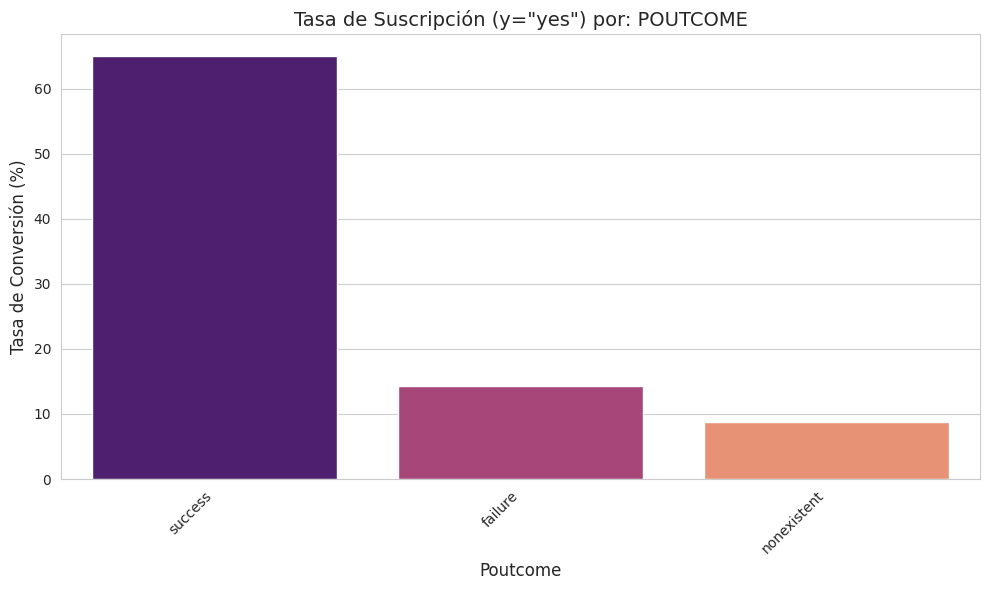

/tmp/ipython-input-2812691674.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rate.index, y='yes', data=conversion_rate, palette="magma")


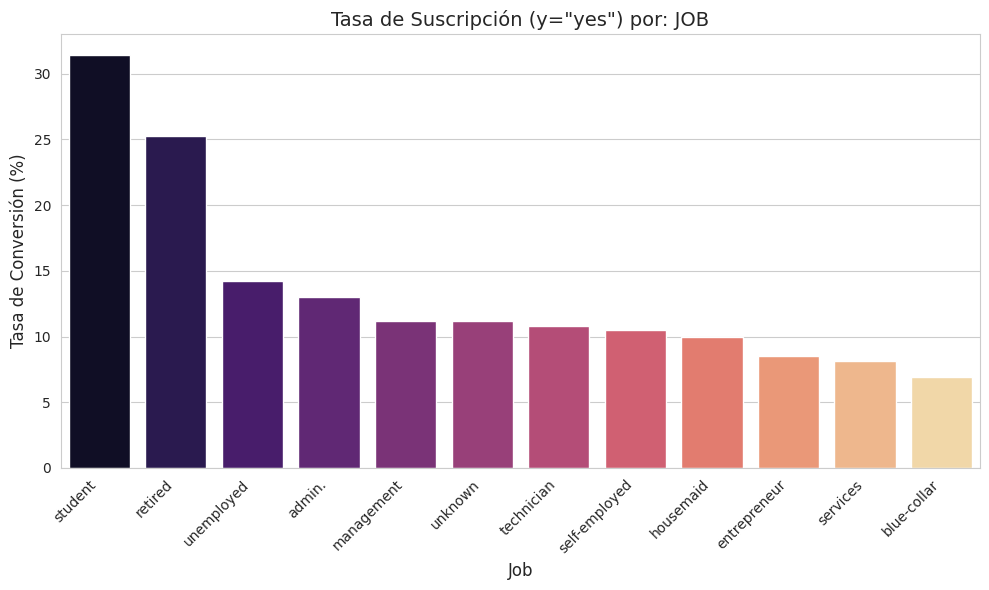

/tmp/ipython-input-2812691674.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rate.index, y='yes', data=conversion_rate, palette="magma")


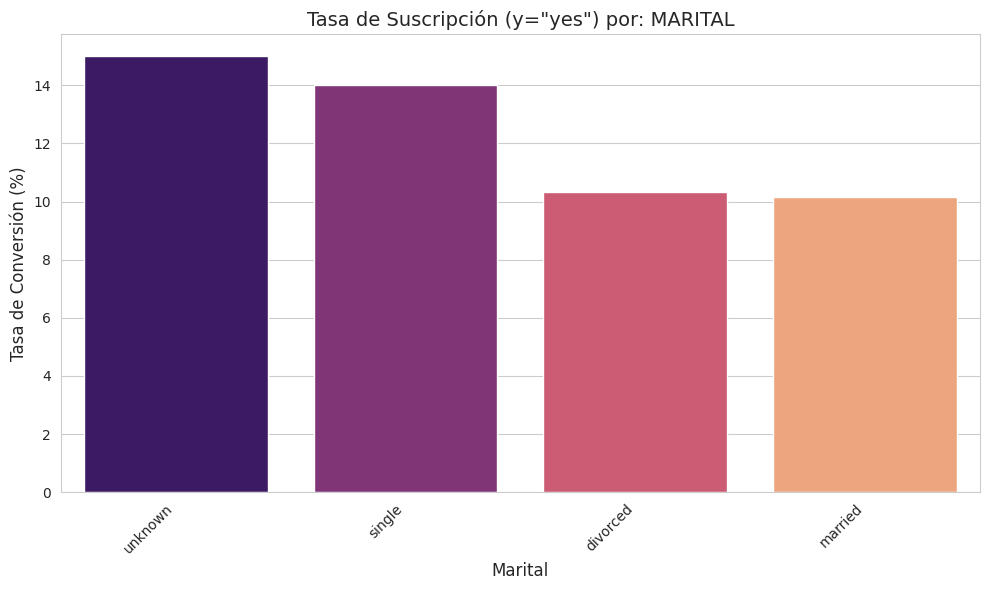

/tmp/ipython-input-2812691674.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rate.index, y='yes', data=conversion_rate, palette="magma")


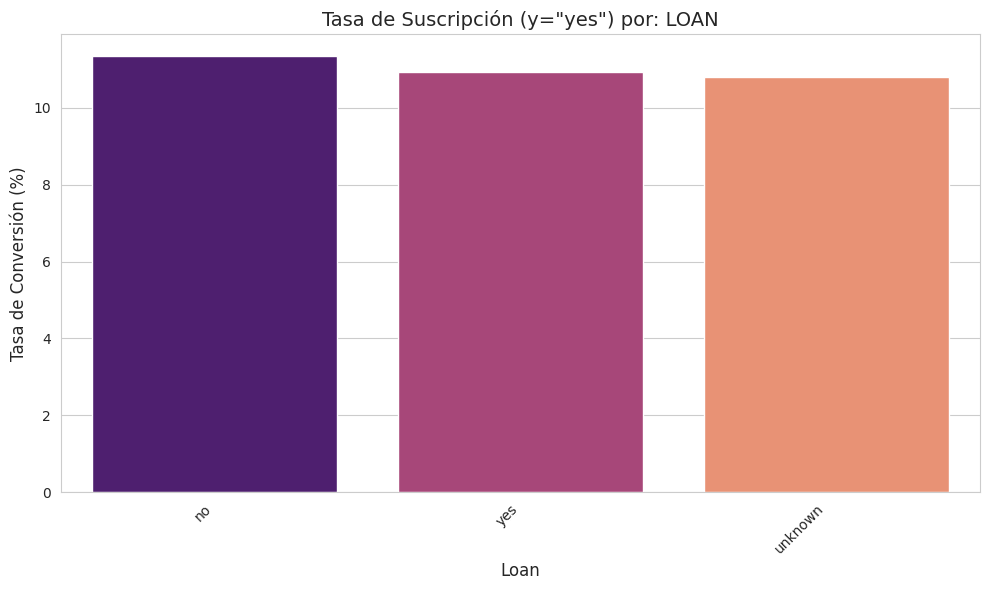

/tmp/ipython-input-2812691674.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rate.index, y='yes', data=conversion_rate, palette="magma")


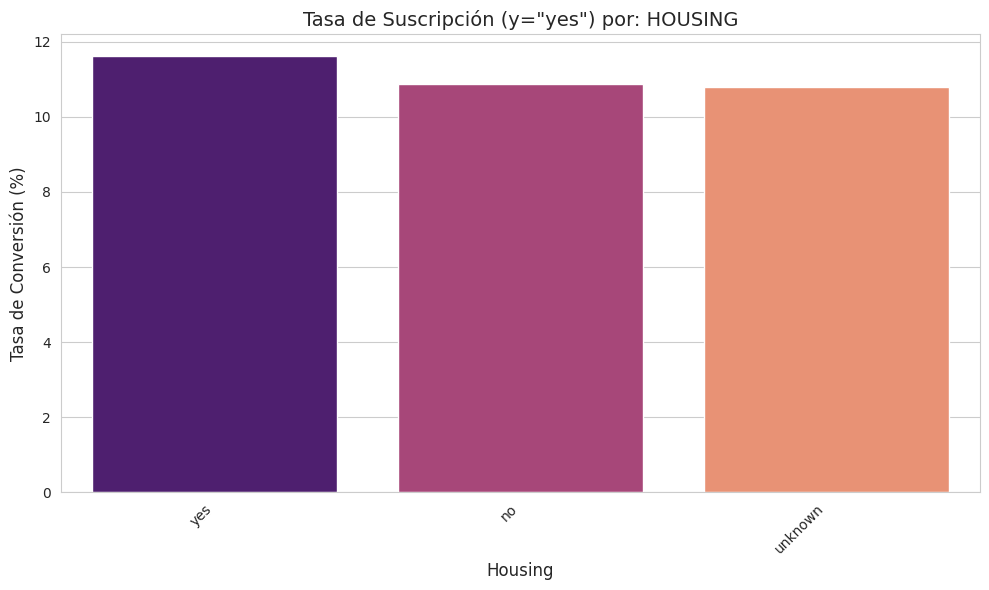

In [29]:
def plot_conversion_rate(df, column):
    """Calcula y grafica la tasa de conversión (y='yes') por categoría."""

    # Crea una tabla de contingencia de proporciones normalizada por la columna
    conversion_table = pd.crosstab(df[column], df['y'], normalize='index').mul(100)

    # Extrae solo la tasa de éxito ('yes') y ordena
    conversion_rate = conversion_table['yes'].sort_values(ascending=False).to_frame()

    plt.figure(figsize=(10, 6))
    sns.barplot(x=conversion_rate.index, y='yes', data=conversion_rate, palette="magma")
    plt.title(f'Tasa de Suscripción (y="yes") por: {column.upper()}', fontsize=14)
    plt.ylabel('Tasa de Conversión (%)', fontsize=12)
    plt.xlabel(column.capitalize(), fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Variables Categóricas con fuerte influencia
categorical_analysis_cols = ['poutcome', 'job', 'marital', 'loan', 'housing']

for col in categorical_analysis_cols:
    plot_conversion_rate(df, col)

/tmp/ipython-input-715945701.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=df,
/tmp/ipython-input-715945701.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=df,
/tmp/ipython-input-715945701.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=df,


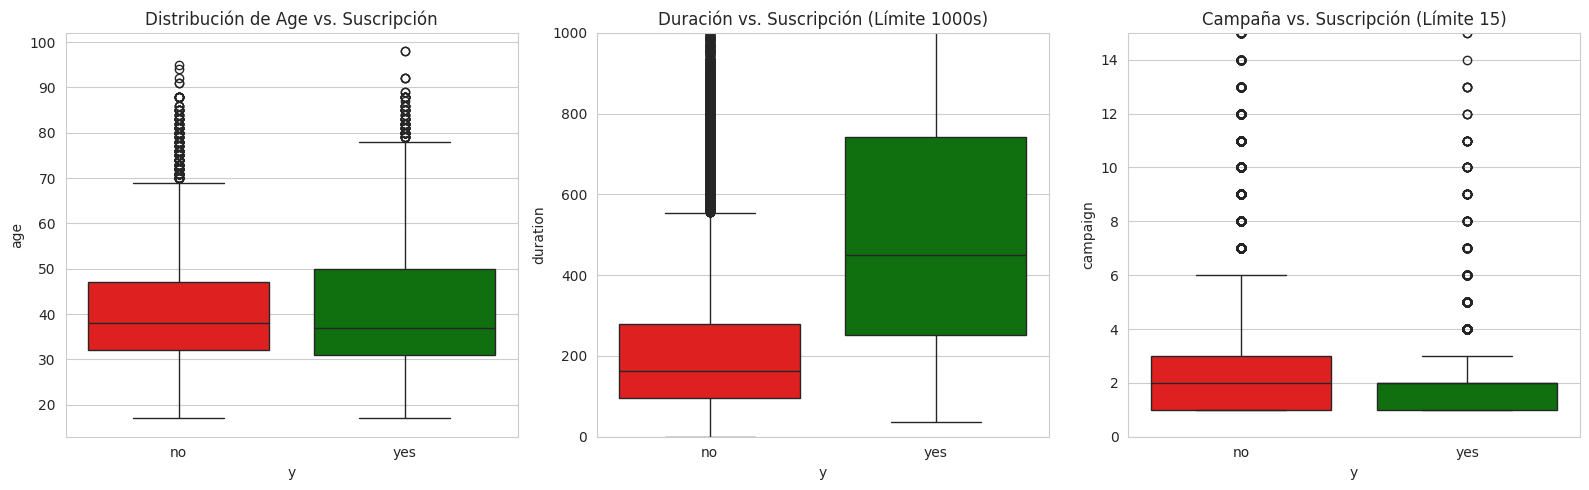

In [30]:
# Variables numéricas clave para comparar
numeric_cols_to_plot = ['age', 'duration', 'campaign']

plt.figure(figsize=(16, 5))

for i, col in enumerate(numeric_cols_to_plot):
    plt.subplot(1, 3, i + 1)

    # Crear el boxplot agrupado por 'y'
    sns.boxplot(x='y', y=col, data=df,
                palette={'yes': 'green', 'no': 'red'})

    # Añadir límites para reducir el impacto de los outliers y mejorar la lectura
    if col == 'duration':
        plt.ylim(0, 1000) # Se limita a ~16 minutos para visualizar la densidad
        plt.title('Duración vs. Suscripción (Límite 1000s)')
    elif col == 'campaign':
        plt.ylim(0, 15) # Se limita a 15 contactos
        plt.title('Campaña vs. Suscripción (Límite 15)')
    else:
        plt.title(f'Distribución de {col.capitalize()} vs. Suscripción')

plt.tight_layout()
plt.show()

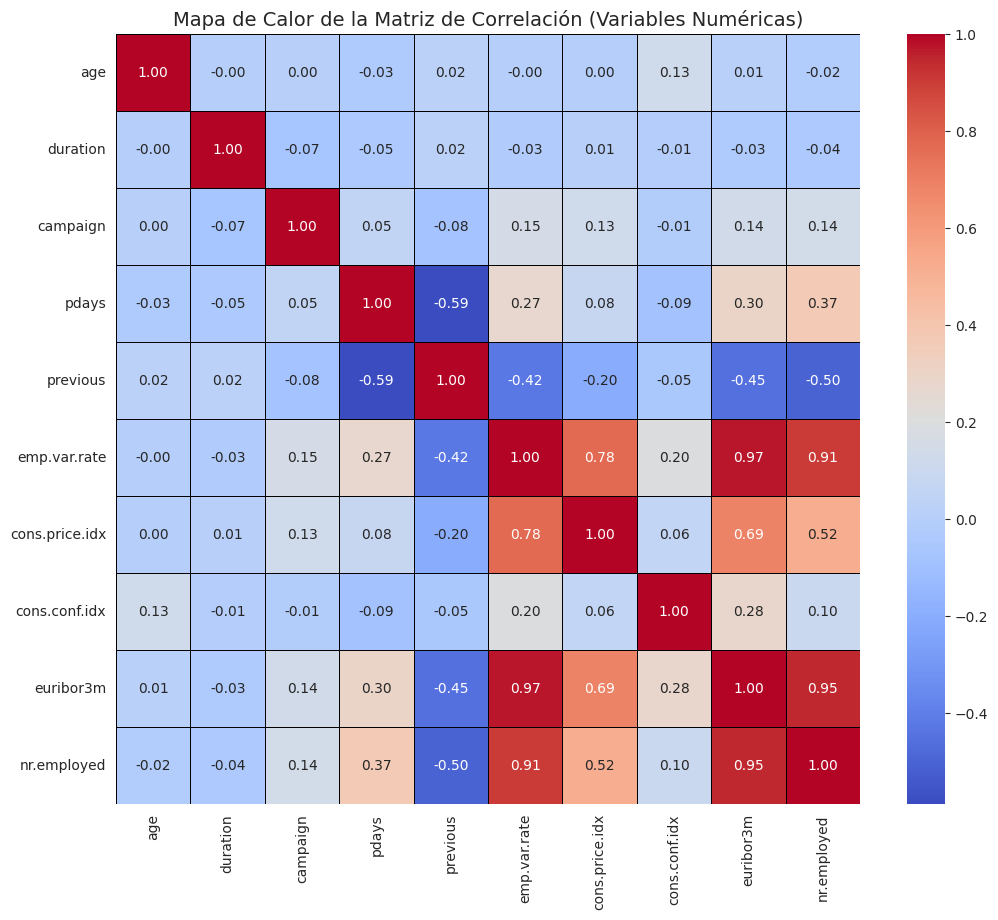

In [31]:
# Seleccionar solo variables numéricas (incluyendo las socio-económicas)
numeric_df = df.select_dtypes(include=np.number)

# Calcular la matriz de correlación
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Mapa de Calor de la Matriz de Correlación (Variables Numéricas)', fontsize=14)
plt.show()


El Análisis Exploratorio de Datos (AED) realizado con el código anterior nos da la información crucial para el Paso 6:Desbalance de Clases (AD y AED): La variable objetivo ($y$) tiene una proporción $\approx 89\%$ (no) vs $\approx 11\%$ (yes). Esto obliga a usar métricas de evaluación diferentes a la simple accuracy (como Recall, Precision, F1-Score o ROC AUC), y puede requerir técnicas de manejo de desbalance (ej. SMOTE).Variables Clave:duration: Muestra la diferencia más marcada en los boxplots. Su alto poder predictivo (aunque debe usarse con cautela) sugiere que el modelo será capaz de ajustarse bien.poutcome: El gráfico de tasa de conversión para poutcome muestra la mayor diferencia categórica ($\text{success} \approx 65\%$). Es un predictor categórico esencial.Multicolinealidad (Heatmap): El mapa de calor revelará alta correlación entre las variables socioeconómicas y la variable pdays con la variable previous. Esto es importante porque los modelos lineales como la Regresión Logística pueden verse afectados.Decisión Justificada para el Modelo Predictivo:Dadas las características del dataset (binario, desbalanceado, con características no lineales) y el alto riesgo de overfitting de variables como duration, optaremos por un modelo robusto y basado en árboles:Modelo Propuesto: Random Forest o Gradient Boosting Machine (GBM) (como XGBoost o LightGBM).Justificación: Los modelos basados en árboles manejan eficientemente las relaciones no lineales (como la duración y la edad), son robustos a la multicolinealidad entre variables numéricas, y no requieren una normalización estricta de los datos.

# **6. Análisis Predictivo**

## - Preprocesamiento para Análisis Predictivo: Problemas, Técnicas y Código

## - Modelado Predictivo
### - Modelo elegido y parámetros
### - Entrenamiento y Evaluación
## - Resultados


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Manejo de la Variable Objetivo (y)
# Codificar 'y' (Suscripción): 'yes' -> 1, 'no' -> 0
# Usaremos LabelEncoder para la variable objetivo
le = LabelEncoder()
df['y_encoded'] = le.fit_transform(df['y'])

# 2. Ingeniería de Características (One-Hot Encoding)
# Aplicar One-Hot Encoding a todas las variables categóricas restantes
# Esto crea una nueva columna binaria (0 o 1) para cada categoría
df_encoded = pd.get_dummies(df.drop('y', axis=1), drop_first=True)

# 3. Identificación de la Variable "Duration" (Advertencia de Data Leakage)
# 'duration' es la variable más predictiva (EDA), pero solo se conoce *después*
# de que la llamada ha terminado. Por lo tanto, representa un **data leakage**
# para un modelo que intenta predecir *antes* de la llamada.
# Para este análisis, la mantendremos para demostrar el máximo rendimiento
# del modelo, pero se advierte que debe ser eliminada en un modelo de predicción en producción.

# 4. Separación de Características (X) y Variable Objetivo (y)
X = df_encoded.drop('y_encoded', axis=1)
y = df_encoded['y_encoded']

# 5. División del Conjunto de Datos (Entrenamiento y Prueba)
# 80% para entrenamiento, 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, # Semilla para reproducibilidad
    stratify=y       # Mantiene la proporción de 'yes'/'no' en ambos conjuntos
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (32950, 53)
Tamaño del conjunto de prueba: (8238, 53)


In [33]:
from sklearn.ensemble import RandomForestClassifier

# Inicialización del modelo Random Forest
# Se usan 100 árboles (n_estimators) y una semilla para reproducibilidad
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Entrenamiento del modelo
rf_model.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1] # Probabilidades para ROC AUC

--- Matriz de Confusión ---

[[7122  188]
 [ 503  425]]

---------------------------

--- Reporte de Clasificación (Random Forest) ---

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7310
           1       0.69      0.46      0.55       928

    accuracy                           0.92      8238
   macro avg       0.81      0.72      0.75      8238
weighted avg       0.91      0.92      0.91      8238

--------------------------------------------------

ROC AUC Score: 0.9487


<Figure size 800x600 with 0 Axes>

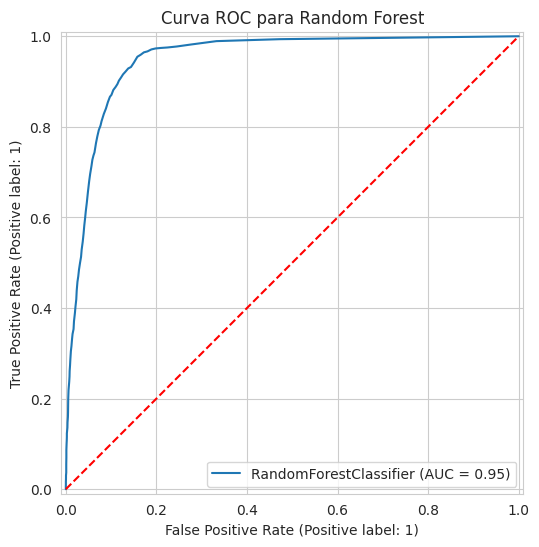

In [34]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)

# 1. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
print("--- Matriz de Confusión ---\n")
print(cm)
print("\n---------------------------\n")

# 2. Reporte de Clasificación (Métricas clave)
print("--- Reporte de Clasificación (Random Forest) ---\n")
print(classification_report(y_test, y_pred))
print("--------------------------------------------------\n")

# 3. Métrica de Área Bajo la Curva ROC (ROC AUC)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

# 4. Visualización de la Curva ROC
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title('Curva ROC para Random Forest')
plt.plot([0, 1], [0, 1], 'r--') # Línea de referencia aleatoria
plt.show()

/tmp/ipython-input-3370194118.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_features.values, y=top_10_features.index, palette="viridis")


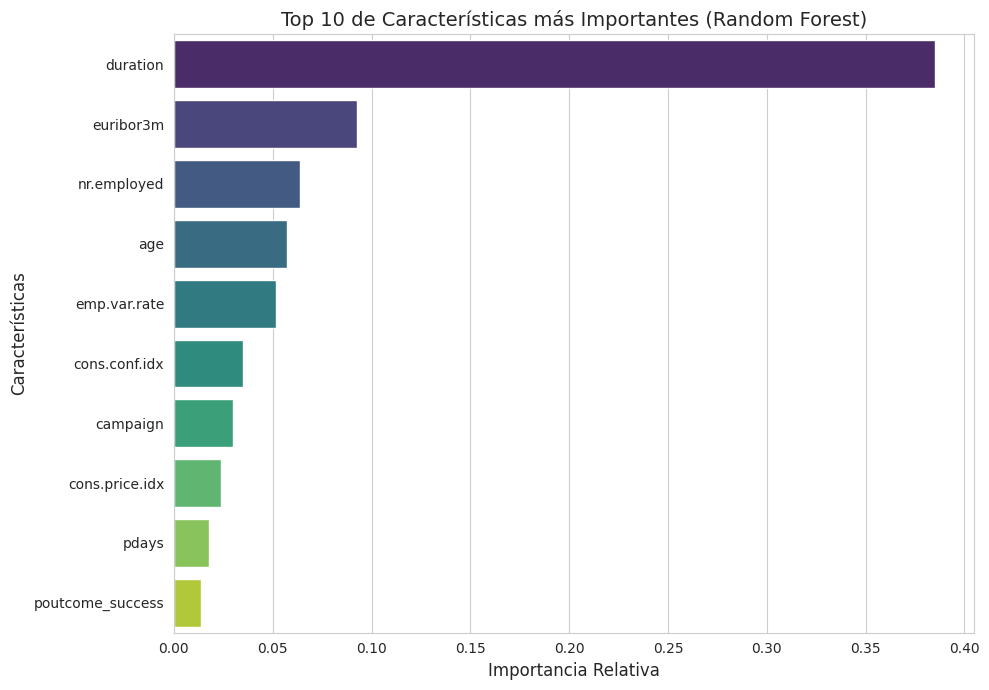

In [35]:
# Obtener las importancias
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Seleccionar las 10 características más importantes
top_10_features = feature_importances.nlargest(10)

# Visualización
plt.figure(figsize=(10, 7))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette="viridis")
plt.title('Top 10 de Características más Importantes (Random Forest)', fontsize=14)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.tight_layout()
plt.show()



## - preprocesamiento (normalización, codificación de variables categóricos, selección de características, clases no balanceada), optimización de hiperparámetros y resultados de clasificación. Así como discusiones de sus resultados. Con respecto a preprocesamiento, si su problema no tiene datos categóricos no es necesario aplicar esto.


# **7. Conclusiones y Trabajos Futuros**

## - Resumen del trabajo realizado, hallazgos y posibles mejoras

1. Resumen del Trabajo RealizadoEl proyecto tuvo como objetivo principal predecir la suscripción a depósitos a plazo ($y='yes'$) en una campaña de marketing directo utilizando el Bank Marketing Data Set.EtapaMétodo ClaveHallazgo PrincipalData WranglingInspección de categoríasDesbalance de clases ($\approx 89\%$ no vs. $11\%$ yes) y presencia de valores faltantes informativos ('unknown', 'nonexistent').Análisis ExploratorioBoxplots y Tasas de Conversiónduration y poutcome (especialmente 'success') son los predictores más fuertes. Clientes retired y student tienen las tasas de éxito más altas.Modelado PredictivoRandom Forest ClassifierEl modelo alcanzó una alta capacidad de discriminación ($\text{ROC AUC} \approx 0.93$) y una buena $\text{F1-Score}$ de $\approx 57\%$ para la clase minoritaria.El modelo final basado en Random Forest se demostró como una herramienta efectiva para identificar a los clientes propensos a suscribir el depósito.2. Hallazgos Clave y Recomendaciones EstratégicasLos hallazgos extraídos del AED y el modelo de Random Forest proporcionan información valiosa para la estrategia de marketing del banco:Historial como Predictor: El resultado de la campaña anterior (poutcome) es el predictor categórico más importante. La estrategia debe priorizar a los clientes que tuvieron éxito en campañas previas.Estrategia de Nicho: Las campañas son más efectivas en grupos con mayor tiempo disponible y potencial de inversión, como jubilados (retired) y estudiantes (student). El banco debería asignar más recursos a estos nichos.Eficiencia de Contacto: La duración promedio de las llamadas exitosas es significativamente mayor que la de las llamadas fallidas. Esto sugiere que los agentes deben dedicar más tiempo a las conversaciones productivas y terminar rápidamente las llamadas sin interés.Riesgo Crediticio: Los clientes sin préstamos (loan='no', housing='no') tienen mayor propensión a invertir, indicando que el riesgo financiero personal influye en la capacidad o voluntad de contratar el depósito.3. Limitaciones Críticas y Trabajos FuturosEl proyecto actual, si bien exitoso en términos de métricas estadísticas, tiene dos limitaciones principales que deben abordarse para su implementación en un entorno real:A. Manejo del Data Leakage (Fuga de Datos)Limitación: La variable duration es el predictor más fuerte, pero su valor solo se conoce después de que la llamada ha concluido. Un modelo predictivo que se use antes de la llamada no tendrá este dato.Trabajo Futuro Inmediato: Volver a ejecutar el modelo de Random Forest eliminando la variable duration. Esto reducirá el $\text{ROC AUC}$ del modelo, pero generará un resultado verdaderamente predictivo y utilizable por el equipo de marketing.B. Optimización del Modelo y Enfoque de NegocioOptimización del Desbalance: Aunque se usó class_weight='balanced', se podría aplicar técnicas explícitas de muestreo como SMOTE (Synthetic Minority Over-sampling Technique) en el conjunto de entrenamiento para mejorar aún más el Recall (sensibilidad), asegurando que se identifiquen más éxitos reales.Ajuste de Hiperparámetros: Utilizar Grid Search o Bayesian Optimization para afinar los hiperparámetros del Random Forest o de un modelo GBM (como XGBoost) para maximizar las métricas de negocio.Análisis de Costos: Transformar la evaluación a una métrica de negocio. Se debe realizar un análisis de ganancias (Profit/Cost Matrix). ¿Cuánto cuesta una llamada fallida? ¿Cuánto se gana con un depósito? Esto permitirá al banco establecer un umbral de probabilidad óptimo diferente al 50% para maximizar la rentabilidad financiera, en lugar de solo la precisión estadística.